In [3]:
#Data manipulation
import pandas as pd
import numpy as np

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


In [4]:
#load dataset
df = pd.read_csv(r"C:\Users\siyan\OneDrive\Desktop\Churn_Modelling.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,"101,348.88",1
1,2,15647311,Hill,608,Spain,Female,41,1,"83,807.86",1,0,1,"112,542.58",0
2,3,15619304,Onio,502,France,Female,42,8,"159,660.80",3,1,0,"113,931.57",1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,"93,826.63",0
4,5,15737888,Mitchell,850,Spain,Female,43,2,"125,510.82",1,1,1,"79,084.10",0


In [6]:
df.shape

(10000, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"5,000.50","15,690,940.57",650.53,38.92,5.01,"76,485.89",1.53,0.71,0.52,"100,090.24",0.20
std,"2,886.90","71,936.19",96.65,10.49,2.89,"62,397.41",0.58,0.46,0.50,"57,510.49",0.40
min,1.00,"15,565,701.00",350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,"2,500.75","15,628,528.25",584.00,32.00,3.00,0.00,1.00,0.00,0.00,"51,002.11",0.00
50%,"5,000.50","15,690,738.00",652.00,37.00,5.00,"97,198.54",1.00,1.00,1.00,"100,193.91",0.00
75%,"7,500.25","15,753,233.75",718.00,44.00,7.00,"127,644.24",2.00,1.00,1.00,"149,388.25",0.00
max,"10,000.00","15,815,690.00",850.00,92.00,10.00,"250,898.09",4.00,1.00,1.00,"199,992.48",1.00


In [10]:
 df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['CustomerId'].duplicated().sum()

np.int64(0)

In [13]:
print("Geography:")
print(df["Geography"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

print("\nNumber Of Products:")
print(df["NumOfProducts"].value_counts())

print("\nExited:")
print(df["Exited"].value_counts())

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Number Of Products:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Exited:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [14]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [15]:
 df['Exited'].value_counts(normalize=True)*100

Exited
0   79.63
1   20.37
Name: proportion, dtype: float64

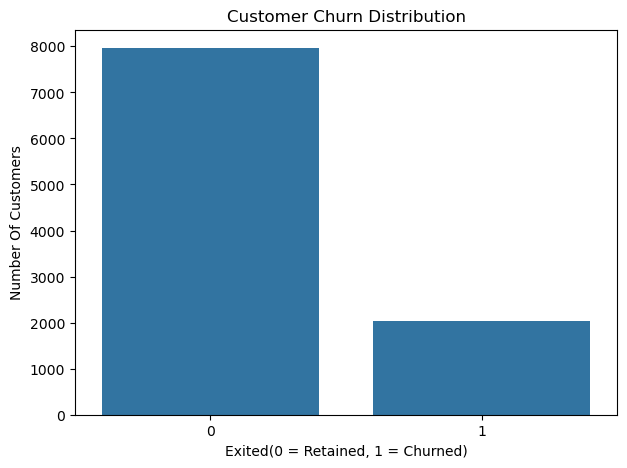

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Exited')
plt.title('Customer Churn Distribution')
plt.xlabel('Exited(0 = Retained, 1 = Churned)')
plt.ylabel('Number Of Customers')
plt.show()

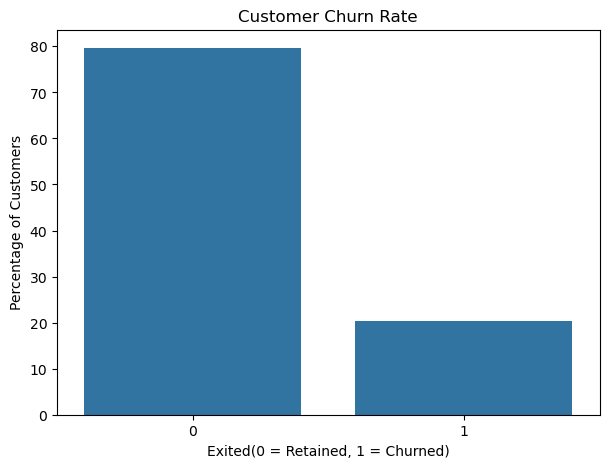

In [17]:
churn_rate = df['Exited'].value_counts(normalize=True)*100
plt.figure(figsize=(7,5))
sns.barplot(x = churn_rate.index, y= churn_rate.values)
plt.title('Customer Churn Rate')
plt.xlabel('Exited(0 = Retained, 1 = Churned)')
plt.ylabel('Percentage of Customers')
plt.show()

In [18]:
#=================================================================
#EDA phase 2 - Univariate analysis
#=================================================================

In [19]:
#Numerical columns
numerical_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'] 
df[numerical_columns].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,650.53,38.92,5.01,"76,485.89",1.53,"100,090.24"
std,96.65,10.49,2.89,"62,397.41",0.58,"57,510.49"
min,350.00,18.00,0.00,0.00,1.00,11.58
25%,584.00,32.00,3.00,0.00,1.00,"51,002.11"
50%,652.00,37.00,5.00,"97,198.54",1.00,"100,193.91"
75%,718.00,44.00,7.00,"127,644.24",2.00,"149,388.25"
max,850.00,92.00,10.00,"250,898.09",4.00,"199,992.48"


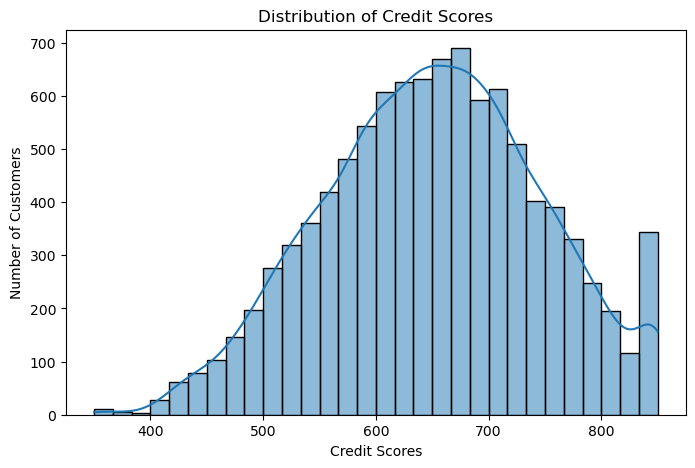

In [20]:
plt.figure(figsize=(8,5))
sns.histplot( data=df, x='CreditScore',bins=30, kde=True)
plt.title('Distribution of Credit Scores')
plt.xlabel('Credit Scores')
plt.ylabel('Number of Customers')
plt.show()

In [21]:
print('Minimum Credit Score:',df['CreditScore'].min())
print('Maximun Credit Score:',df['CreditScore'].max())
print('Average CreditScore:',df['CreditScore'].mean())
print('Median Credit Score:',df['CreditScore'].median())

Minimum Credit Score: 350
Maximun Credit Score: 850
Average CreditScore: 650.5288
Median Credit Score: 652.0


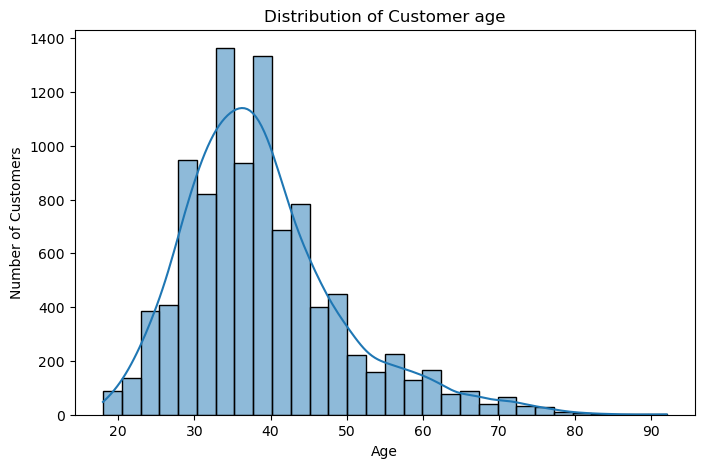

In [22]:
plt.figure(figsize= (8,5))
sns.histplot (data=df, x= 'Age',bins =30, kde = True)
plt.title('Distribution of Customer age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

In [23]:
print('Minimum Age:',df['Age'].min())
print('Maximum Age:',df['Age'].max())
print('Average Age:',df['Age'].mean())
print('Median Age:',df['Age'].median())

Minimum Age: 18
Maximum Age: 92
Average Age: 38.9218
Median Age: 37.0


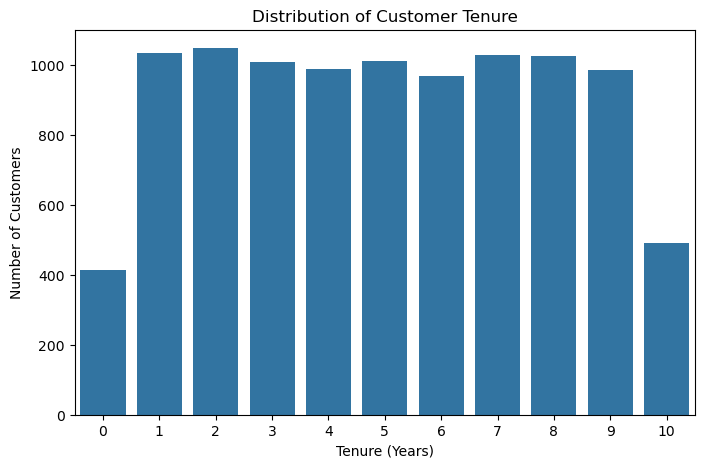

In [24]:
plt.figure(figsize =(8, 5))
sns.countplot(data=df, x='Tenure')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Number of Customers')
plt.show()


In [25]:
df['Tenure'].value_counts().sort_index()

Tenure
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: count, dtype: int64

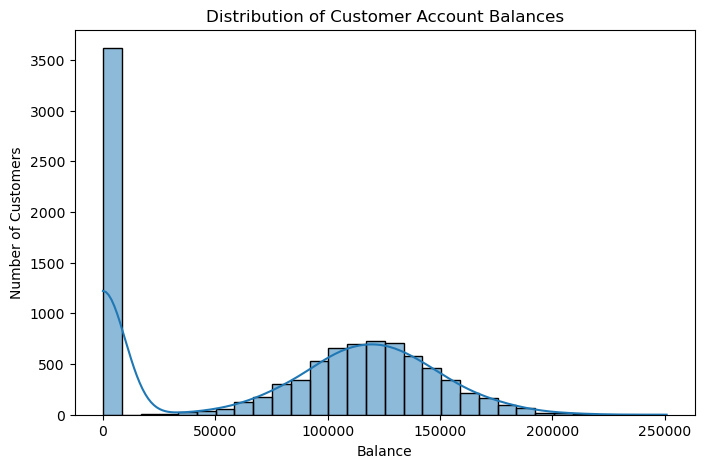

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Balance',bins=30, kde=True)
plt.title('Distribution of Customer Account Balances')
plt.xlabel('Balance')
plt.ylabel('Number of Customers')
plt.show()

In [27]:
print('Minimum Balance:',df['Balance'].min())
print('Maximum Balance:',df['Balance'].max())
print('Average Balance:',df['Balance'].mean())
print('Median Balance:',df['Balance'].median())

Minimum Balance: 0.0
Maximum Balance: 250898.09
Average Balance: 76485.889288
Median Balance: 97198.54000000001


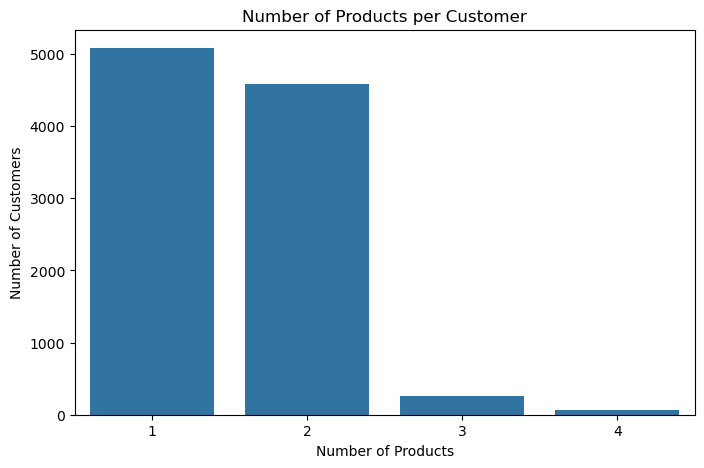

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='NumOfProducts')
plt.title('Number of Products per Customer')
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.show()

In [29]:
df['NumOfProducts'].value_counts().sort_index()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

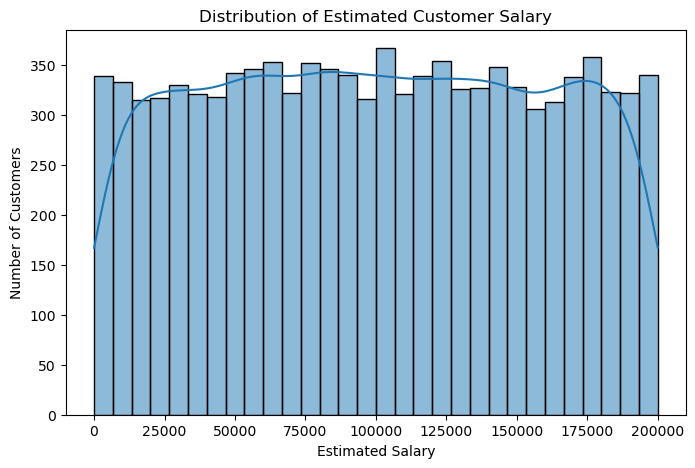

In [30]:
plt.figure(figsize= (8,5))
sns.histplot(data=df, x='EstimatedSalary', bins=30, kde=True)
plt.title('Distribution of Estimated Customer Salary')
plt.xlabel('Estimated Salary')
plt.ylabel('Number of Customers')
plt.show()

In [31]:
print('Minimum Salary:',df['EstimatedSalary'].min())
print('Maximum Salary:',df['EstimatedSalary'].max())
print('Average Salary:',df['EstimatedSalary'].mean())
print('Median Salary:',df['EstimatedSalary'].median())

Minimum Salary: 11.58
Maximum Salary: 199992.48
Average Salary: 100090.239881
Median Salary: 100193.915


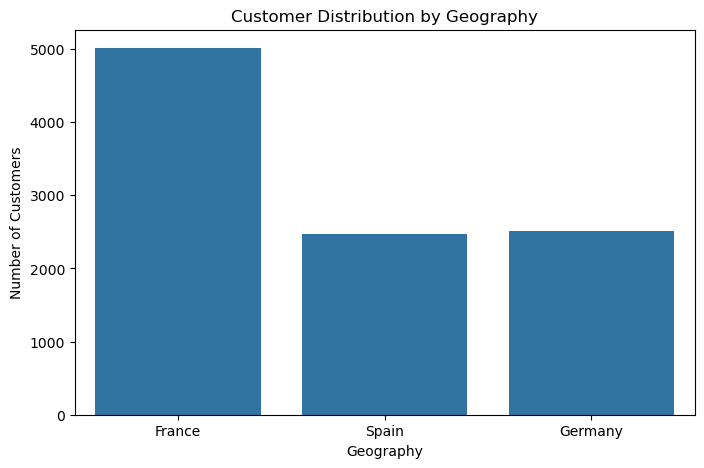

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Geography')
plt.title('Customer Distribution by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')
plt.show()

In [33]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [34]:
df['Geography'].value_counts(normalize=True).mul(100).round(2)

Geography
France    50.14
Germany   25.09
Spain     24.77
Name: proportion, dtype: float64

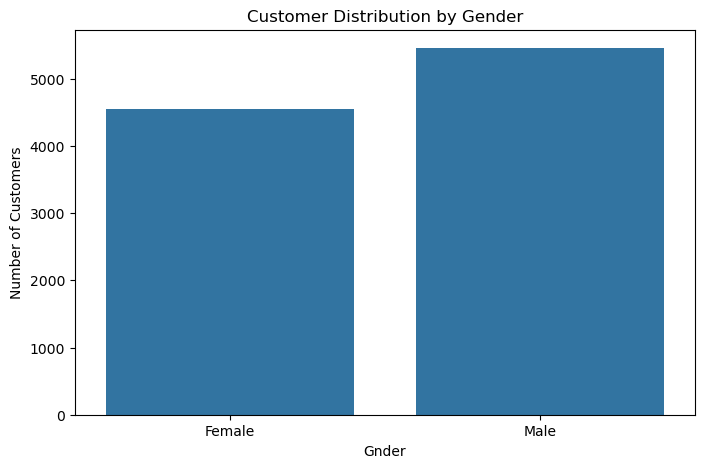

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender')
plt.title('Customer Distribution by Gender')
plt.xlabel('Gnder')
plt.ylabel('Number of Customers')
plt.show()

In [36]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

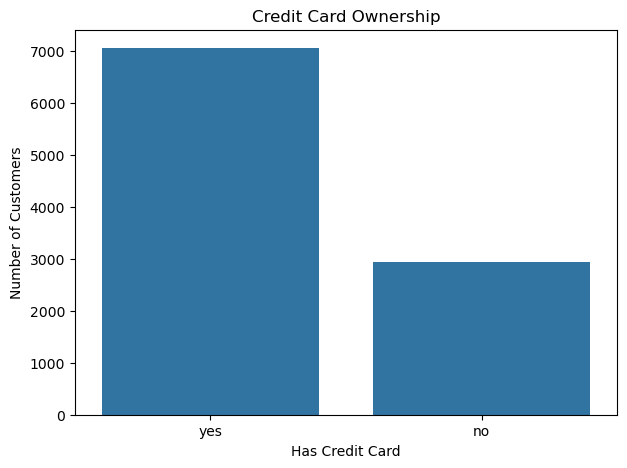

In [37]:
credit_card_labels = df['HasCrCard'].map({0 :'no',1 :'yes'})
plt.figure(figsize=(7,5))
sns.countplot( x = credit_card_labels)
plt.title('Credit Card Ownership')
plt.xlabel('Has Credit Card')
plt.ylabel('Number of Customers')
plt.show()


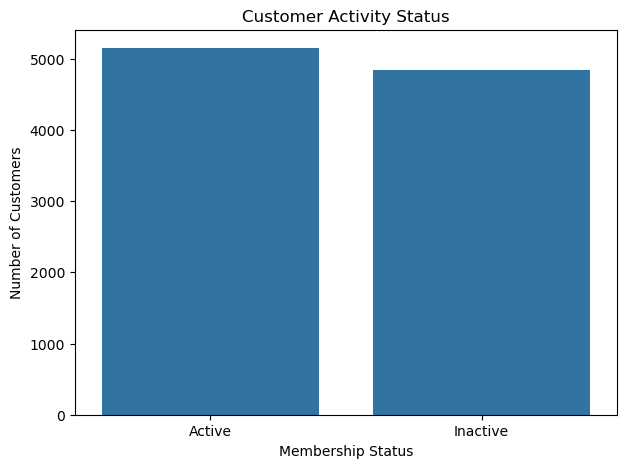

In [38]:
active_labels= df['IsActiveMember'].map({0:'Inactive', 1:'Active'})
plt.figure(figsize=(7,5))
sns.countplot(x= active_labels)
plt.title('Customer Activity Status')
plt.xlabel('Membership Status')
plt.ylabel('Number of Customers')
plt.show()

In [39]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

In [40]:
univariate_summary = pd.DataFrame({
    'Data type': df.dtypes,
     'unique values':df.nunique(),
     'missing Values': df.isnull().sum()
    })
univariate_summary

,Data type,unique values,missing Values
RowNumber,int64,10000,0
CustomerId,int64,10000,0
Surname,object,2932,0
CreditScore,int64,460,0
Geography,object,3,0
Gender,object,2,0
Age,int64,70,0
Tenure,int64,11,0
Balance,float64,6382,0
NumOfProducts,int64,4,0


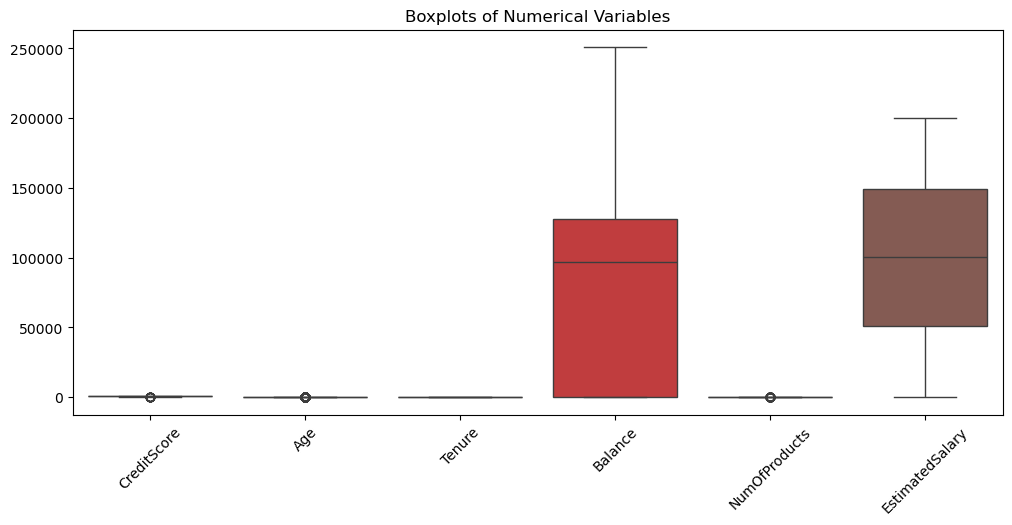

In [41]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df[numerical_columns])
plt.title('Boxplots of Numerical Variables')
plt.xticks(rotation = 45)
plt.show()

In [42]:
age_bins = [0,25,35,45,55,65,100]
age_labels = ['18-25','26-35','36-45','46-55','56-65','66+']
df['AgeGroup'] = pd.cut(df['Age'], bins= age_bins, labels=age_labels, include_lowest= True)

In [43]:
df['AgeGroup'].value_counts().sort_index()

AgeGroup
18-25     611
26-35    3542
36-45    3736
46-55    1311
56-65     536
66+       264
Name: count, dtype: int64

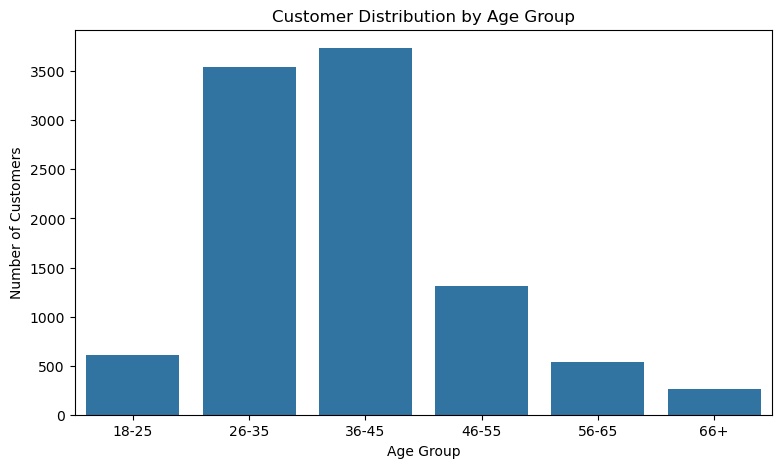

In [44]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x= 'AgeGroup')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

In [45]:
#======================================================================
#Phase3
#======================================================================


In [46]:
churn_summary = df.groupby('Exited').size().reset_index(name='Customers')
churn_summary['Status'] = churn_summary['Exited'].map({0: 'Retained', 1:'churned'})
churn_summary['Percentage'] = (churn_summary['Customers']/len(df)*100).round(2)
churn_summary[['Status', 'Customers', 'Percentage']]

,Status,Customers,Percentage
0,Retained,7963,79.63
1,churned,2037,20.37


In [47]:
geography_churn = (df.groupby('Geography')['Exited'].agg(['count', 'sum', 'mean']).reset_index())
geography_churn.columns = ['Geography', 'Total Customers', 'Churned Customers','Churn Rate']
geography_churn['Churn Rate'] = (geography_churn['Churn Rate'] * 100).round(2)
geography_churn.sort_values('Churn Rate', ascending=False)

,Geography,Total Customers,Churned Customers,Churn Rate
1,Germany,2509,814,32.44
2,Spain,2477,413,16.67
0,France,5014,810,16.15


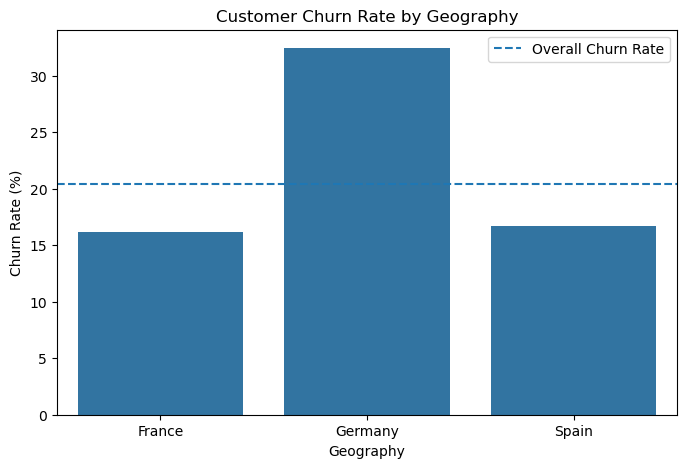

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(data=geography_churn, x='Geography',y='Churn Rate')
plt.axhline(y=20.37,linestyle='--',label= 'Overall Churn Rate')
plt.title('Customer Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.show()


In [49]:
gender_churn = (df.groupby('Gender')['Exited'].agg(['count','sum','mean']).reset_index())
gender_churn.columns = ['Gender','Total Customers', 'Churned Customers','Churn Rate']
gender_churn['Churn Rate']= (gender_churn['Churn Rate']*100).round(2)
gender_churn.sort_values('Churn Rate',ascending=False)


,Gender,Total Customers,Churned Customers,Churn Rate
0,Female,4543,1139,25.07
1,Male,5457,898,16.46


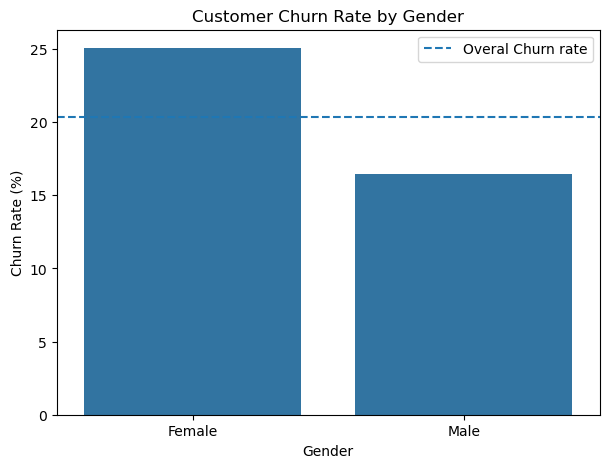

In [50]:
plt.figure(figsize=(7,5))
sns.barplot(data=gender_churn, x='Gender', y= 'Churn Rate')
plt.axhline(y = 20.37, linestyle='--', label= 'Overal Churn rate')
plt.title('Customer Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.show()

In [51]:
age_churn= (df.groupby('AgeGroup',observed=True)['Exited'].agg(['count','sum','mean']).reset_index())
age_churn.columns= ['Age Group','Total Customers','Churned Customers','Churn Rate']
age_churn['Churn Rate']=(age_churn['Churn Rate']*100).round(2)
age_churn











,Age Group,Total Customers,Churned Customers,Churn Rate
0,18-25,611,46,7.53
1,26-35,3542,301,8.50
2,36-45,3736,733,19.62
3,46-55,1311,663,50.57
4,56-65,536,259,48.32
5,66+,264,35,13.26


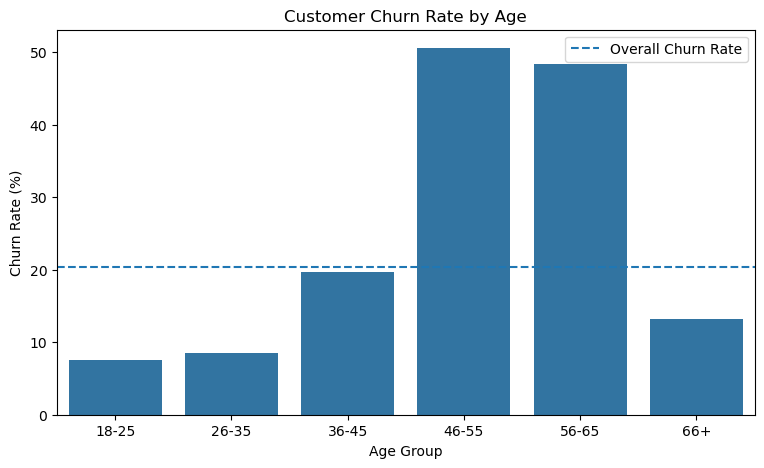

In [52]:
plt.figure(figsize=(9,5))
sns.barplot(data=age_churn, x='Age Group', y= 'Churn Rate')
plt.axhline( y= 20.37, linestyle='--',label= 'Overall Churn Rate')
plt.title('Customer Churn Rate by Age')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.show()

In [53]:
product_churn= (df.groupby('NumOfProducts')['Exited'].agg(['count','sum','mean']).reset_index())
product_churn.columns= ['Number of Products','Total Customers','Churned Customers','Churn Rate']
product_churn['Churn Rate']= (product_churn['Churn Rate']*100).round(2)
product_churn


,Number of Products,Total Customers,Churned Customers,Churn Rate
0,1,5084,1409,27.71
1,2,4590,348,7.58
2,3,266,220,82.71
3,4,60,60,100.00


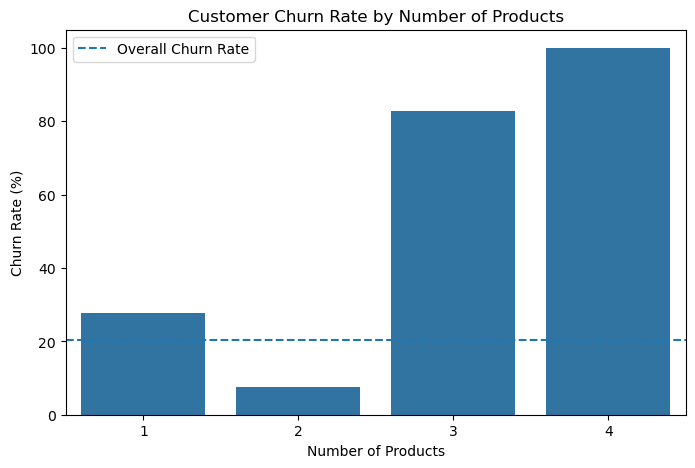

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(data= product_churn, x='Number of Products', y='Churn Rate')
plt.axhline(y=20.37, linestyle='--',label = 'Overall Churn Rate')
plt.title('Customer Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.show()

In [55]:
activity_churn = (df.groupby('IsActiveMember')['Exited'].agg(['count', 'sum', 'mean']).reset_index())
activity_churn.columns = ['Active Member','Total Customers','Churned Customers','Churn Rate']
activity_churn['Membership Status'] = activity_churn['Active Member'].map({0: 'Inactive',1: 'Active'})
activity_churn['Churn Rate'] = (activity_churn['Churn Rate'] * 100).round(2)
activity_churn[['Membership Status', 'Total Customers','Churned Customers','Churn Rate']]

,Membership Status,Total Customers,Churned Customers,Churn Rate
0,Inactive,4849,1302,26.85
1,Active,5151,735,14.27


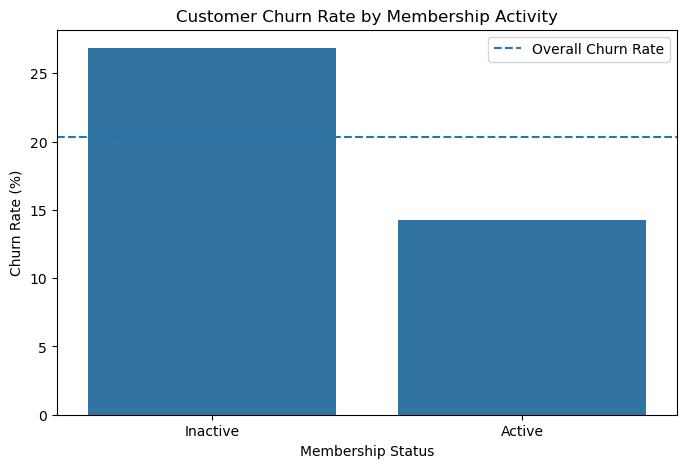

In [58]:
plt.figure(figsize=(8, 5))
sns.barplot(data=activity_churn, x='Membership Status', y='Churn Rate')
plt.axhline(y=20.37, linestyle='--', label='Overall Churn Rate')
plt.title('Customer Churn Rate by Membership Activity')
plt.xlabel('Membership Status')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.show()

In [60]:
credit_card_churn = (df.groupby('HasCrCard')['Exited'].agg(['count', 'sum', 'mean']).reset_index())
credit_card_churn.columns = ['Has Credit Card','Total Customers','Churned Customers','Churn Rate']
credit_card_churn['Credit Card Status'] = (credit_card_churn)['Has Credit Card'].map({ 0: 'No',1: 'Yes'})
credit_card_churn['Churn Rate'] = (credit_card_churn['Churn Rate'] * 100).round(2)
credit_card_churn[['Credit Card Status','Total Customers','Churned Customers','Churn Rate']]

,Credit Card Status,Total Customers,Churned Customers,Churn Rate
0,No,2945,613,20.81
1,Yes,7055,1424,20.18


In [61]:
tenure_churn = (df.groupby('Tenure')['Exited'].agg(['count', 'sum', 'mean']).reset_index())
tenure_churn.columns = ['Tenure','Total Customers','Churned Customers','Churn Rate']
tenure_churn['Churn Rate'] = (tenure_churn['Churn Rate'] * 100).round(2)
tenure_churn

,Tenure,Total Customers,Churned Customers,Churn Rate
0,0,413,95,23.00
1,1,1035,232,22.42
2,2,1048,201,19.18
3,3,1009,213,21.11
4,4,989,203,20.53
5,5,1012,209,20.65
6,6,967,196,20.27
7,7,1028,177,17.22
8,8,1025,197,19.22
9,9,984,213,21.65


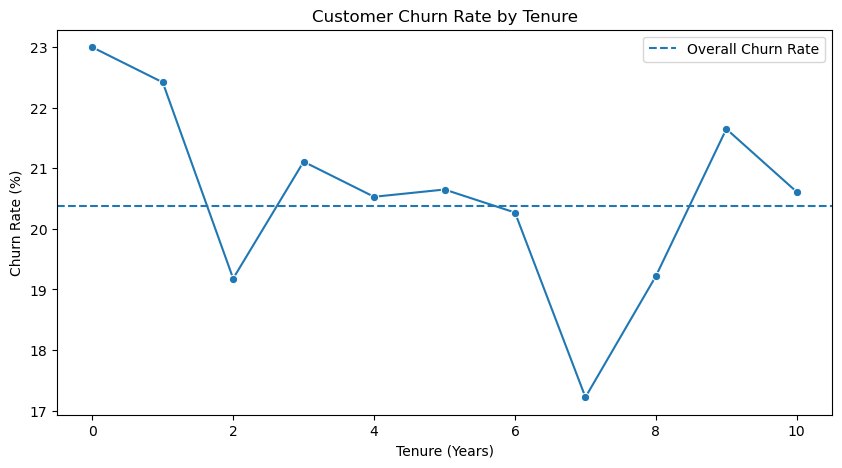

In [62]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=tenure_churn, x='Tenure', y='Churn Rate', marker='o')
plt.axhline(y=20.37, linestyle='--', label='Overall Churn Rate')
plt.title('Customer Churn Rate by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.show()

In [63]:
credit_bins = [0, 579, 669, 739, 799, 850]
credit_labels = ['Poor','Fair','Good','Very Good','Exceptional']
df['CreditScoreBand'] = pd.cut(df['CreditScore'],bins=credit_bins,labels=credit_labels)

In [64]:
credit_churn = (df.groupby('CreditScoreBand', observed=True)['Exited'].agg(['count', 'sum', 'mean']).reset_index())
credit_churn.columns = ['Credit Score Band','Total Customers','Churned Customers','Churn Rate']
credit_churn['Churn Rate'] = (credit_churn['Churn Rate'] * 100).round(2)
credit_churn

,Credit Score Band,Total Customers,Churned Customers,Churn Rate
0,Poor,2362,520,22.02
1,Fair,3331,685,20.56
2,Good,2428,452,18.62
3,Very Good,1224,252,20.59
4,Exceptional,655,128,19.54


In [65]:
balance_bins = [-1, 0, 50000, 100000, 150000, 200000, np.inf]
balance_labels = ['Zero Balance','1–50K','50K–100K','100K–150K','150K–200K','200K+']
df['BalanceBand'] = pd.cut(df['Balance'], bins=balance_bins,labels=balance_labels)

In [67]:
balance_churn = (df.groupby('BalanceBand', observed=True)['Exited'].agg(['count', 'sum', 'mean']).reset_index())
balance_churn.columns = ['Balance Band','Total Customers','Churned Customers','Churn Rate']
balance_churn['Churn Rate'] = (balance_churn['Churn Rate'] * 100).round(2)
balance_churn

,Balance Band,Total Customers,Churned Customers,Churn Rate
0,Zero Balance,3617,500,13.82
1,1–50K,75,26,34.67
2,50K–100K,1509,300,19.88
3,100K–150K,3830,987,25.77
4,150K–200K,935,205,21.93
5,200K+,34,19,55.88


In [69]:
correlation_matrix = df[['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary','Exited']].corr()
correlation_matrix['Exited'].sort_values( ascending=False)

Exited             1.00
Age                0.29
Balance            0.12
EstimatedSalary    0.01
HasCrCard         -0.01
Tenure            -0.01
CreditScore       -0.03
NumOfProducts     -0.05
IsActiveMember    -0.16
Name: Exited, dtype: float64

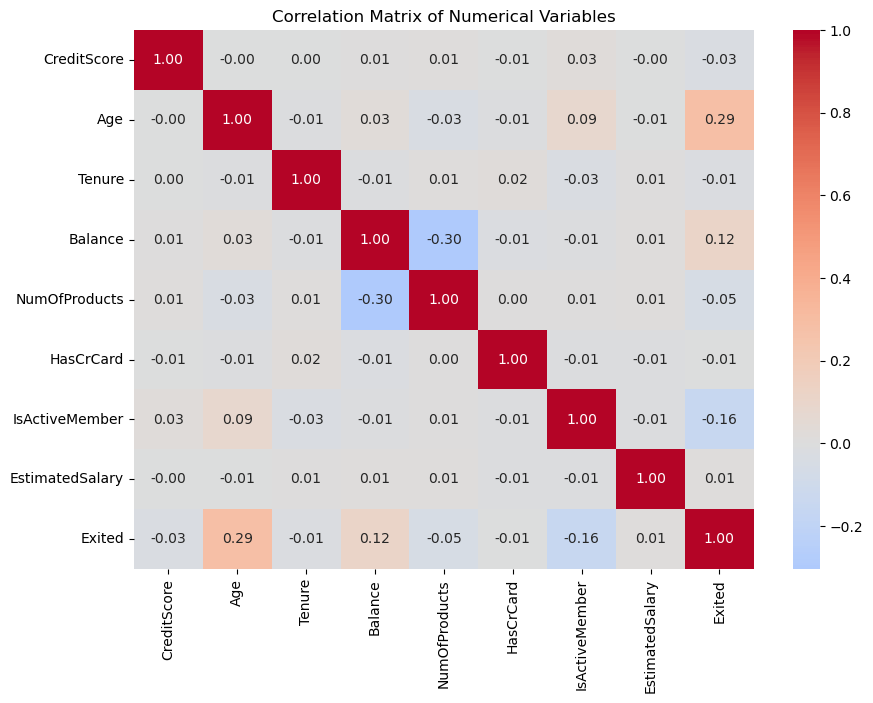

In [70]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [71]:
churn_analysis_summary = {
    'Geography': geography_churn,
    'Gender': gender_churn,
    'Age Group': age_churn,
    'Number of Products': product_churn,
    'Active Membership': activity_churn,
    'Credit Card': credit_card_churn,
    'Tenure': tenure_churn,
    'Credit Score': credit_churn,
    'Balance': balance_churn
}
churn_analysis_summary

{'Geography':   Geography  Total Customers  Churned Customers  Churn Rate
 0    France             5014                810       16.15
 1   Germany             2509                814       32.44
 2     Spain             2477                413       16.67,
 'Gender':    Gender  Total Customers  Churned Customers  Churn Rate
 0  Female             4543               1139       25.07
 1    Male             5457                898       16.46,
 'Age Group':   Age Group  Total Customers  Churned Customers  Churn Rate
 0     18-25              611                 46        7.53
 1     26-35             3542                301        8.50
 2     36-45             3736                733       19.62
 3     46-55             1311                663       50.57
 4     56-65              536                259       48.32
 5       66+              264                 35       13.26,
 'Number of Products':    Number of Products  Total Customers  Churned Customers  Churn Rate
 0                  

In [72]:
from sqlalchemy import create_engine

server = "localhost"
database = "Customer_churn"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

table_name = "churn"

df.to_sql(
    table_name,
    con=engine,
    if_exists="replace",
    index=False
)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'churn' in database 'Customer_churn'.
